<a href="https://colab.research.google.com/github/Blazingshadows/Agentic-AI-Labs/blob/main/Copy_of_Part_4_FCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1 – The Fully Connected Neural Network (FCNN)

**How an FCNN Reads Text**

An FCNN requires a fixed input size. To feed it text, we use a Sliding Window.

If our window size is 3, we give the model 3 characters, and its entire job is to guess the 4th character.


```
Text: "learning"

Window 1:  [ l , e , a ]  ---> Predicts: 'r'

Window 2:  [ e , a , r ]  ---> Predicts: 'n'

Window 3:  [ a , r , n ]  ---> Predicts: 'i'
```

Because an FCNN is Fully Connected, every neuron in the input layer connects to every neuron in the hidden layer. It cannot handle sequences dynamically; it requires us to flatten our 3 characters into one single, flat vector.

# Step 1: Text Tokenization & Dataset Preparation

Computers don't understand letters; they understand numbers. Run the following code block to convert a sample 500-word text into unique integer IDs and slice them into our 3-character windows.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. The Raw Text Data (A snapshot of deep learning history)
text = """Deep learning is a subset of machine learning, which is essentially a neural network with three or more layers.
These neural networks attempt to simulate the behavior of the human brain though far from matching its ability,
allowing it to learn from large amounts of data. While a neural network with a single layer can still make
approximate predictions, additional hidden layers can help to optimize and refine for accuracy."""

# 2. Extract unique characters (Our Vocabulary)
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Unique characters in vocabulary: {vocab_size}")

# 3. Create conversion dictionaries
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# 4. Slide the window of 3 characters across the dataset
window_size = 9
X_data = []
Y_data = []

encoded_text = [char_to_int[ch] for ch in text]

for i in range(len(encoded_text) - window_size):
    X_data.append(encoded_text[i : i + window_size])  # Input: 3 characters
    Y_data.append(encoded_text[i + window_size])      # Target: The next character

# Convert data into PyTorch Tensors
X_tensor = torch.tensor(X_data, dtype=torch.long)
Y_tensor = torch.tensor(Y_data, dtype=torch.long)

print(f"Prepared Input Shape (X): {X_tensor.shape} -> [Total Windows, Window Size]")
print(f"Prepared Target Shape (Y): {Y_tensor.shape} -> [Total Windows]")

Unique characters in vocabulary: 31
Prepared Input Shape (X): torch.Size([417, 9]) -> [Total Windows, Window Size]
Prepared Target Shape (Y): torch.Size([417]) -> [Total Windows]


# Step 2: Building the FCNN Architecture
In this step, we map our characters to continuous numbers using an nn.Embedding layer, flatten the temporal sequence dimension, and pass it to a standard Fully Connected hidden layer.

In [ ]:
class FCNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(FCNNLanguageModel, self).__init__()
        # Embedding maps each unique character integer to a dense vector
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # CRITICAL CALCULATION:
        # Because we have 3 characters and each character has 'embedding_dim' features,
        # flattening them means the input to our linear layer must be 3 * embedding_dim.
        self.fc1 = nn.Linear(window_size * embedding_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, vocab_size) # Outputs scores for all possible next characters

    def forward(self, x):
        # Input 'x' shape: [batch_size, window_size]
        embeds = self.embedding(x)  # Shape: [batch_size, 3, embedding_dim]

        # FLATTENING STEP: Collapse the sequence dimension into a single flat vector
        flattened = embeds.view(embeds.size(0), -1)  # Shape: [batch_size, 3 * embedding_dim]

        out = self.fc1(flattened)
        out = self.relu(out)
        logits = self.fc2(out)
        return logits  # Shape: [batch_size, vocab_size]

# Initialize model hyper-parameters
EMBED_DIM = 16
HIDDEN_SIZE = 64
model = FCNNLanguageModel(vocab_size, EMBED_DIM, HIDDEN_SIZE)
print(model)

FCNNLanguageModel(
  (embedding): Embedding(31, 16)
  (fc1): Linear(in_features=144, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=31, bias=True)
)


# Step 3: The Optimization Loop
We will train the network over 100 iterations (epochs). The network will evaluate its errors using **CrossEntropyLoss** and adjust its internal weights using the **Adam** optimizer.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
loss_list = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    predictions = model(X_tensor)   # Forward pass
    loss = criterion(predictions, Y_tensor) # Compute error

    loss.backward()  # Backward pass (compute gradients)
    optimizer.step() # Update weights
    loss_list.append(loss.item())

    if (epoch + 1) % 20 == 0:
      print(f"Epoch {epoch+1:03d}/{epochs} | Training Loss: {loss.item():.4f}")

Epoch 020/100 | Training Loss: 0.3421
Epoch 040/100 | Training Loss: 0.0155
Epoch 060/100 | Training Loss: 0.0122
Epoch 080/100 | Training Loss: 0.0119
Epoch 100/100 | Training Loss: 0.0117


# Step 4: Text Generation & The Limits of FCNNs
Let's see the model in action. We provide it with a seed phrase of 3 characters ("Dee"), it predicts the 4th character, drops the first character from its memory window, appends the prediction, and slides forward.

In [ ]:
def generate_text(model, seed_str, length=100):
    model.eval()
    if len(seed_str) != window_size:
        return f"Error: Seed must be exactly {window_size} characters!"

    generated = seed_str
    current_context = [char_to_int[ch] for ch in seed_str]

    with torch.no_grad():
        for _ in range(length):
            input_tensor = torch.tensor([current_context], dtype=torch.long)
            output = model(input_tensor)

            # Select the character with the absolute highest probability score
            predicted_int = torch.argmax(output, dim=1).item()
            generated += int_to_char[predicted_int]

            # Slide window forward: drop index 0, append new character ID
            current_context = current_context[1:] + [predicted_int]

    return generated

print("--- GENERATED TEXT OUTPUT ---")
print(generate_text(model, seed_str="Deep lear", length=150))
print("-----------------------------")

--- GENERATED TEXT OUTPUT ---
Deep learning is a subset of machine learning is a subset of machine learning is a subset of machine learning is a subset of machine learning is a subset of ma
-----------------------------


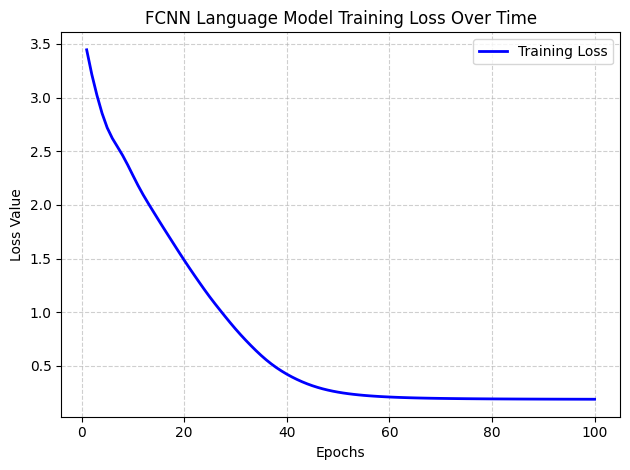

In [ ]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(range(1, epochs + 1), loss_list, label='Training Loss', color='blue', linewidth=2)

# Adding labels and styling
plt.title('FCNN Language Model Training Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Display or save the layout
plt.tight_layout()
plt.savefig('loss_curve.png') # Use this to save it as an image file
plt.show()                    # Use this to display it directly inside Google Colab / Jupyter